## Inference from real data: the Shine-Dalgarno sequence

In this section, we will show how to use SeqDEFT to infer and analyze the genotype-phenotype map of the Shine-Dalgarno (SD) sequence as in our original paper [(Martí-Gómez et al. 2025)](https://www.biorxiv.org/content/10.1101/2025.03.09.642267v3). For full reproducibility of the analysis of the Shine-Dalgarno landscape, including processing of the raw data, see the associated [repository](https://github.com/cmarti/shine_dalgarno). 


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gpmap.plot.mpl as plot

from scipy.special import logsumexp
from scipy.stats import pearsonr
from gpmap.inference import SeqDEFT
from gpmap.seq import calc_msa_weights, get_subsequences
from gpmap.space import SequenceSpace
from gpmap.randwalk import WMWalk
from gpmap.datasets import DataSet, list_available_datasets

### Loading natural Shine-Dalgarno sequences from the *E.coli* genome

Here, for simplicity, we use the built-in dataset provided by `gpmap-tools` for the Shine-Dalgarno sequence as inferred from the collection of 5'UTR sequences in the *E.coli* genome. 

In [ ]:
dataset = DataSet('shine_dalgarno')
dataset.data

,X
0,AAAAAAGGU
1,AAAAACAUC
2,AAAAACGUA
3,AAAAAGAAU
4,AAAAAGGAA
...,...
5306,UUUUGUACU
5307,UUUUUGAGG
5308,UUUUUGCCG
5309,UUUUUUAUA


We can see that there is a large number of observations along the human genome. Previous efforts have used pairwise Maximum Entropy models to characterize the splice sites probability distributions along the genome ([Yeo and Burge (2004)](https://pubmed.ncbi.nlm.nih.gov/15285897/)). In what follows, we relax the constrains of this pairwise model to allow variability in the local pairwise epistatic coefficients by specifying `P=2`. To reduce the computational burden and for simplicity, we have previously selected the sequences that have the cannonical GU at positions +1 and +2 and investigate the dependencies on the other positions: -3 to -1 together with +3 to +6.

### Inference with SeqDEFT

In [25]:
model = SeqDEFT(P=2, seq_length=7, alphabet_type='dna')
inferred = model.fit(X=X)

100%|██████████| 115/115 [07:10<00:00,  3.74s/it]


Note that fitting the model for a dataset this large takes a long time. For illustration purposes, we can use the estimated probability distribution from the built-in dataset

In [26]:
inferred

,frequency,phi,Q_star
AAAAAAA,0.000129,8.999252,1.234873e-04
AAAAAAC,0.000058,9.783342,5.637630e-05
AAAAAAG,0.000133,8.953524,1.292653e-04
AAAAAAT,0.000272,8.217149,2.699516e-04
AAAAACA,0.000017,10.881680,1.879727e-05
...,...,...,...
TTTTTGT,0.000010,11.846418,7.163314e-06
TTTTTTA,0.000014,13.704795,1.116944e-06
TTTTTTC,0.000000,14.840094,3.589032e-07
TTTTTTG,0.000003,14.548814,4.802620e-07


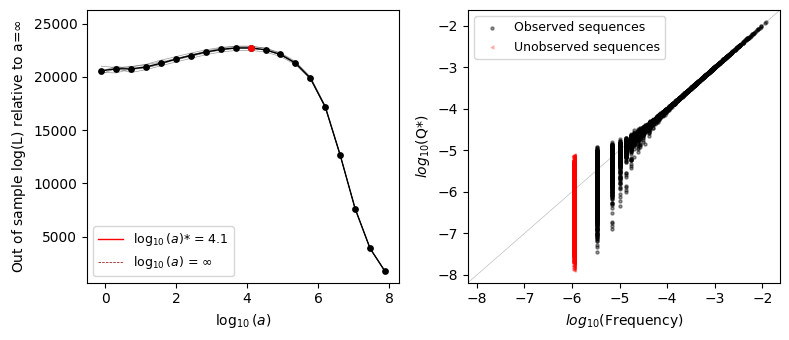

In [27]:
fig = plot.plot_SeqDEFT_summary(model.logL_df, inferred, show_folds=True, legend_loc=3)

We can see how the probability of sequences that have been observed a fair number of times matches their frequency in the dataset, but there is a large variation, of several orders of magnitude in the probability of sequences that have been observed only a few times in the dataset or none at all, as highlithed in red

### Landscape visualization

In [28]:
space = SequenceSpace(X=inferred.index.values, y=np.log(inferred['Q_star']))
print(space)

Sequence Space:
	Type: dna
	Sequence length: 7
	Number of alleles per site: [4, 4, 4, 4, 4, 4, 4]
	Genotypes: [AAAAAAA,AAAAAAC,AAAAAAG,...,TTTTTTC,TTTTTTG,TTTTTTT]
	Function y: [-9.00,-9.78,-8.95,...,-14.84,-14.55,-12.77]


In [29]:
rw = WMWalk(space)
rw.calc_visualization(Ns=1)
ndf, edf = rw.nodes_df, space.get_edges_df()
ndf['2'] = -ndf['2']
ndf['1'] = -ndf['1']
ndf.index = np.array([seq[:3] + 'GT' + seq[3:] for seq in ndf.index])

After generating the coordinates of the visualization and re-inserting the GT sequence at +1 and +2, we can plot the resulting landscape and highlight the sequences that were previously reported to characterize qualitatively different solutions to the 5'splice site recognition ([Chen et al. 2022](https://www.pnas.org/doi/10.1073/pnas.2025782118))

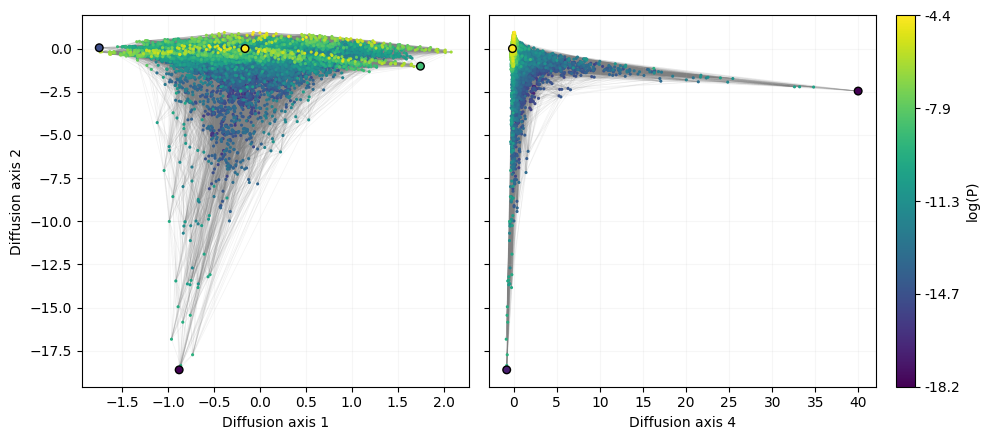

In [30]:
fig, subplots = plt.subplots(1, 3, figsize=(10, 4.5), width_ratios=(0.5, 0.5, 0.025))
cbar_ax = subplots[-1]

axes = subplots[0]
plot.plot_visualization(axes, ndf, edges_df=edf, nodes_size=5,
                        nodes_cmap_label='log(P)', nodes_cbar_axes=cbar_ax)
seqs = ['CAGGTTCAA', 'CAGGTAAGT', 'TCTGTAAGT',
        'ACTGTATCC']
plot.plot_nodes(axes, ndf.loc[seqs, :], size=30, lw=1, edgecolor='black', cbar=False)
axes.grid(alpha=0.1)

axes = subplots[1]
plot.plot_visualization(axes, ndf, edges_df=edf, nodes_size=5, x='4',
                        nodes_cmap_label='log(P)', nodes_cbar=False)
seqs = ['CAGGTAAGT', 'ACTGTATCC',
        'ACAGTTAAG']
plot.plot_nodes(axes, ndf.loc[seqs, :], size=30, lw=1, edgecolor='black', cbar=False, x='4')
axes.set(ylabel='', yticklabels=[])
axes.grid(alpha=0.1)

fig.tight_layout()